## 정규분포
관련 분포: $ t, \chi^2, F $

In [1]:
# 정규분포표 표 작성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats   # 이렇게 하면 stats.norm(어쩌구)
from scipy.stats import norm  # 이렇게 하면 norm(어쩌구...


### 밀도함수
$ X \sim N(\mu, \sigma^2 ) $, 이때 $ X $의 밀도 at $ x $.
 $$ f(x) = {1 \over \sqrt{2 \pi \sigma^2} } e^{ -{1 \over 2\sigma^2} (x - \mu)^2 } $$

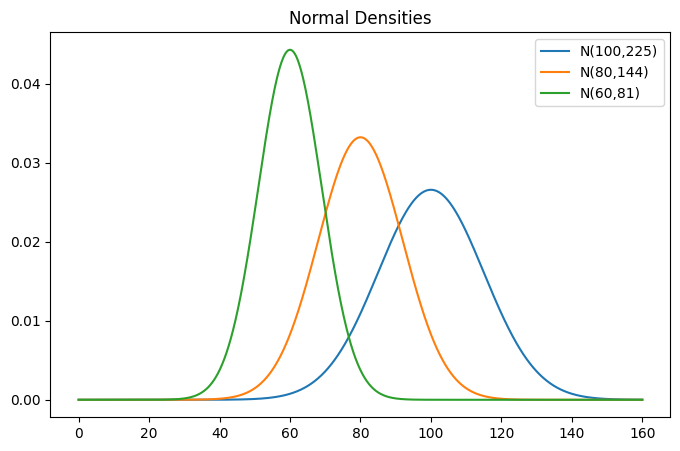

In [2]:
# 이런 저런 정규분포의 pdf 생성

mu_s = [100, 80, 60]
sig_s = [15, 12, 9]
x_beg = min(mu_s) - 4*max(sig_s)
x_end = max(mu_s) + 4*max(sig_s)
x = np.linspace(x_beg, x_end, 1000)

plt.figure(figsize=(16/2, 10/2))     # 황금비 근사.

for mu, sig in zip(mu_s, sig_s):
  y = norm.pdf(x, loc=mu, scale=sig)
  plt.plot(x, y, label=f"N({mu},{sig**2})")

#plt.plot(x, y, color='black', label=f"std={sig}")   # density
plt.title(f'Normal Densities')
plt.legend()


### 경험법칙, 누적확률
$ P(a< X< b ) = P(X<b) - P(X<a) $

P(X <= 75.3250) = 0.0500
P(75.3250 <= X <= 124.6750) = 0.9000
P(X <= 30.2600) = 0.0500
P(30.2600 <= X <= 69.7400) = 0.9000
P(X <= -14.8050) = 0.0500
P(-14.8050 <= X <= 14.8050) = 0.9000


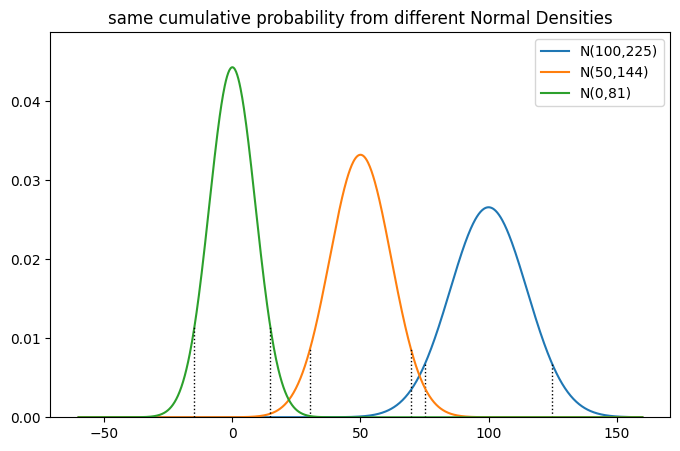

In [26]:
# 이런 저런 정규분포의 pdf 생성

mu_s = [100, 50, 0]
sig_s = [15, 12, 9]
x_beg = min(mu_s) - 4*max(sig_s)
x_end = max(mu_s) + 4*max(sig_s)
x = np.linspace(x_beg, x_end, 1000)

rule_mpr = 1.645  # 경험법칙

plt.figure(figsize=(16/2, 10/2))     # 황금비 근사.

for mu, sig in zip(mu_s, sig_s):
  y = norm.pdf(x, loc=mu, scale=sig)
  y_max = max(y)
  plt.plot(x, y, label=f"N({mu},{sig**2})")
  x_ref_1 = mu - rule_mpr * sig                # 경계선 표시
  x_ref_2 = mu + rule_mpr * sig                # 경계선 표시
  x_look_1 = [ x_ref_1, x_ref_1 ]                  # 경계선 표시
  x_look_2 = [ x_ref_2, x_ref_2 ]                  # 경계선 표시
  y_look_1 = [0, norm.pdf(x_look_1[1], mu, sig)] # 경계산 표시
  y_look_2 = [0, norm.pdf(x_look_2[1], mu, sig)] # 경계산 표시
  p_1 = norm.cdf(x_look_1[1], mu, sig)
  p_2 = norm.cdf(x_look_2[1], mu, sig)
  plt.plot(x_look_1, y_look_1, color='black', lw=1, linestyle='dotted') # reference line
  plt.plot(x_look_2, y_look_2, color='black', lw=1, linestyle='dotted') # reference line
  plt.ylim(0, y_max*1.1)

  print(f'P(X <= {x_look_1[1] :.4f}) = {p_1 :.4f}')
  print(f'P({x_look_1[1] :.4f} <= X <= {x_look_2[1] :.4f}) = {1-2* p_1:.4f}')

plt.title(f'same cumulative probability from different Normal Densities')
plt.legend()


### 유의수준, 임계치
$ P(a<X<b) = 1- \alpha $,

where
$ P(X<a )= P(X>b)$

P(X <= 78.4070) = 0.0750
P(78.4070 <= X <= 121.5930) = 0.8500
P(X <= 32.7256) = 0.0750
P(32.7256 <= X <= 67.2744) = 0.8500
P(X <= -12.9558) = 0.0750
P(-12.9558 <= X <= 12.9558) = 0.8500


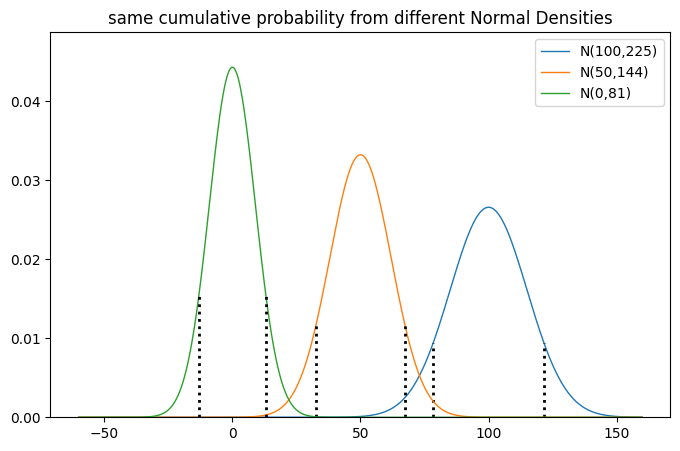

In [25]:
# 이런 저런 정규분포의 pdf 생성

mu_s = [100, 50, 0]
sig_s = [15, 12, 9]
x_beg = min(mu_s) - 4*max(sig_s)
x_end = max(mu_s) + 4*max(sig_s)
x = np.linspace(x_beg, x_end, 1000)

rule_mpr = 1.65    # 경험법칙
alpha = 0.15       # 유의수준

plt.figure(figsize=(16/2, 10/2))     # 황금비 근사.

for mu, sig in zip(mu_s, sig_s):
  y = norm.pdf(x, loc=mu, scale=sig)
  y_max = max(y)
  plt.plot(x, y, label=f"N({mu},{sig**2})", lw=1)
  x_ref_1 = norm.ppf(alpha/2, mu, sig)         # 유의수준 임계치, 경계선 표시
  x_ref_2 = norm.ppf(1-alpha/2, mu, sig)         # 유의수준 임계치, 경계선 표시
  x_look_1 = [ x_ref_1, x_ref_1 ]                  # 경계선 표시
  x_look_2 = [ x_ref_2, x_ref_2 ]                  # 경계선 표시
  y_look_1 = [0, norm.pdf(x_look_1[1], mu, sig)] # 경계산 표시
  y_look_2 = [0, norm.pdf(x_look_2[1], mu, sig)] # 경계산 표시
  plt.plot(x_look_1, y_look_1, color='black', lw=2, linestyle='dotted') # reference line
  plt.plot(x_look_2, y_look_2, color='black', lw=2, linestyle='dotted') # reference line
  plt.ylim(0, y_max*1.1)

  print(f'P(X <= {x_ref_1 :.4f}) = { alpha/2 :.4f}')
  print(f'P({x_ref_1 :.4f} <= X <= {x_ref_2 :.4f}) = { 1-alpha :.4f}')

plt.title(f'same cumulative probability from different Normal Densities')
plt.legend()
